## __Latar Belakang__

Dalam industri e-commerce, **mempertahankan pelanggan** dan **mengidentifikasi pelanggan terbaik** merupakan aspek krusial untuk menjaga kelangsungan bisnis dan meningkatkan pertumbuhan penjualan. Seiring dengan tren belanja online yang terus meningkat, perusahaan-perusahaan e-commerce, seperti **Perusahaan XYZ E-Commerce**, perlu terus berinovasi dalam mengembangkan strategi pemasaran yang efektif, khususnya terkait dengan retensi pelanggan.

**Perusahaan XYZ E-Commerce** adalah platform yang menyediakan berbagai macam produk, seperti **furnitur**, **alat tulis kantor (ATK)**, dan **elektronik**. Dengan semakin banyak pelanggan yang berbelanja dari berbagai wilayah, perusahaan mengumpulkan sejumlah besar data transaksi. Data ini dapat digunakan untuk **memahami perilaku pelanggan**, yang sangat penting untuk menyusun strategi guna menjaga hubungan dengan pelanggan dan meningkatkan penjualan mereka.

Untuk itu, perusahaan perlu menerapkan **analisis RFM** (**Recency, Frequency, Monetary**) untuk mengidentifikasi pelanggan terbaik, memahami pola belanja, serta merumuskan strategi yang lebih tepat guna meningkatkan loyalitas pelanggan dan memaksimalkan pendapatan.

---

## __Pernyataan Masalah__

Seiring dengan meningkatnya jumlah pelanggan dan transaksi di **Perusahaan XYZ E-Commerce**, perusahaan menghadapi tantangan dalam mengelola pelanggan secara efektif. Tantangan utama yang dihadapi antara lain:

1. **Menjaga pelanggan agar tetap loyal**: Beberapa pelanggan mungkin hanya berbelanja satu atau dua kali, lalu tidak kembali. Perusahaan membutuhkan cara untuk mengidentifikasi pelanggan yang masih aktif dan merumuskan strategi yang efektif untuk meningkatkan **frekuensi pembelian** mereka.
   
2. **Mengidentifikasi pelanggan terbaik**: Dari sekian banyak pelanggan, ada yang memberikan kontribusi besar dalam hal **frekuensi dan nilai pembelian**. Penting untuk mengidentifikasi pelanggan bernilai tinggi ini dan memastikan mereka tetap puas serta loyal kepada perusahaan.

Dengan menggunakan analisis RFM, kita dapat mengelompokkan pelanggan berdasarkan **waktu pembelian terakhir (Recency)**, **frekuensi pembelian (Frequency)**, dan **nilai total pembelian (Monetary)**. Berdasarkan data ini, kita dapat menjawab pertanyaan-pertanyaan penting, seperti:

- Siapa saja pelanggan terbaik yang perlu mendapatkan perhatian khusus dari perusahaan?
- Bagaimana cara meningkatkan loyalitas pelanggan yang berpotensi untuk menjadi lebih setia?
- Pelanggan mana yang berisiko untuk tidak kembali berbelanja, dan bagaimana cara memulihkan mereka?

---

## __Data__

Untuk menjawab pertanyaan-pertanyaan di atas, digunakan dataset penjualan dari **Perusahaan XYZ E-Commerce** untuk periode **2011 hingga 2014**, yang mencakup data transaksi, produk, dan pelanggan. Data ini akan dianalisis menggunakan model **RFM** untuk memberikan skor berdasarkan:

1. **Recency**: Jarak waktu sejak transaksi terakhir pelanggan hingga tanggal referensi (contohnya, 1 Januari 2015). Semakin baru transaksinya, semakin tinggi skor recency yang diberikan.
   
2. **Frequency**: Jumlah total transaksi yang dilakukan oleh pelanggan dalam periode tertentu. Semakin sering pelanggan berbelanja, semakin tinggi frekuensinya, dan semakin tinggi skornya.
   
3. **Monetary**: Total uang yang dihabiskan oleh pelanggan selama periode tersebut. Semakin besar nilai pembelian pelanggan, semakin tinggi skor monetary yang diberikan.

### Dataset ini terdiri dari kolom-kolom berikut yang relevan untuk analisis RFM:
- **Order ID**: ID unik untuk setiap transaksi.
- **Order Date**: Tanggal transaksi dilakukan.
- **Customer Name**: Nama pelanggan yang melakukan transaksi.
- **Sales**: Total uang yang dihasilkan dari setiap transaksi.

Melalui data ini, segmen pelanggan akan dibuat berdasarkan skor RFM untuk membantu merumuskan **strategi pemasaran yang lebih terarah**, seperti **kampanye retensi pelanggan**, **peningkatan frekuensi pembelian**, dan **program loyalitas**.

---


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Import Dataset
df = pd.read_excel('sales-superstore-activation.xlsx')
df.head(3)

,Order ID,Order Date,Customer Name,Country,State,City,Region,Segment,Ship Mode,Category,Sub-Category,Product Name,Discount,Sales,Profit,Quantity,Feedback?
0,AZ-2014-1412225,2014-12-31,Leon Barnes,United Kingdom,England,Worcester,North,Consumer,Priority,Office Supplies,Storage,"Fellowes Shelving, Single Width",0.0,289,75,5,True
1,AZ-2014-4217323,2014-12-31,Evie Morton,France,Normandy,Caen,Central,Consumer,Economy Plus,Office Supplies,Storage,"Fellowes Lockers, Wire Frame",0.1,557,217,3,False
2,AZ-2014-8174835,2014-12-31,Eloise Sykes,Germany,North Rhine-Westphalia,Bielefeld,Central,Consumer,Economy,Office Supplies,Supplies,"Kleencut Shears, Serrated",0.0,261,13,6,True


In [6]:
# Mengganti nama kolom menjadi 'Recency', 'Frequency', 'Monetary'
df.rename(columns={
    'Order Date': 'Recency',
    'Order ID': 'Frequency',
    'Sales': 'Monetary'
}, inplace=True)

In [7]:
# Menghapus Kolom yang tidak digunakan
df.drop(columns=['Country', 'State', 'City', 'Region', 'Segment', 'Ship Mode', 'Category', 'Sub-Category', 'Product Name', 'Discount', 'Profit', 'Quantity', 'Feedback?'], inplace=True)

In [8]:
df.head()

,Frequency,Recency,Customer Name,Monetary
0,AZ-2014-1412225,2014-12-31,Leon Barnes,289
1,AZ-2014-4217323,2014-12-31,Evie Morton,557
2,AZ-2014-8174835,2014-12-31,Eloise Sykes,261
3,AZ-2014-7604524,2014-12-31,Rebecca Chamberlain,32
4,AZ-2014-766953,2014-12-31,Jose Gambino,245


# __1. Data Understanding__

Pada tahap ini, dilakukan pemahaman yang lebih mendalam terhadap dataset yang digunakan, seperti mengidentifikasi anomali, kesalahan, ketidakkonsistenan, serta error dalam data. Selanjutnya, proses perapihan atau pembersihan data akan dilakukan agar dataset dapat memberikan hasil analisis yang lebih akurat.

#### __a. Melihat Bentuk Dataset__
Dataset yang digunakan memiliki __8047__ baris __4__ kolom

In [9]:
df.shape

(8047, 4)

#### __b. Melihat datatype dan jumlah data masing-masing Kolom__

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8047 entries, 0 to 8046
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Frequency      8047 non-null   object        
 1   Recency        8047 non-null   datetime64[ns]
 2   Customer Name  8047 non-null   object        
 3   Monetary       8047 non-null   int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 251.6+ KB


#### __c. Menampilkan statistik deskriptif dari dataset__

In [11]:
# Data Numerik
df.describe()

,Recency,Monetary
count,8047,8047.000000
mean,2013-04-19 12:25:40.748104704,291.845657
min,2011-01-01 00:00:00,3.000000
25%,2012-06-08 00:00:00,48.000000
50%,2013-06-11 00:00:00,117.000000
75%,2014-04-30 00:00:00,313.000000
max,2014-12-31 00:00:00,6517.000000
std,NaN,485.212156


In [12]:
# Data Kategorikal
df.describe(include=object)

,Frequency,Customer Name
count,8047,8047
unique,4117,792
top,AZ-2014-7040665,Joel Peters
freq,11,32


#### __d. Mengecek duplikasi data pada dataset__

In [13]:
# Cek Duplikat
df[df.duplicated()]

,Frequency,Recency,Customer Name,Monetary
525,AZ-2014-6559589,2014-11-12,Natasha Sykes,88
648,BN-2014-3503687,2014-10-30,Angus Ibsch,43
1218,AZ-2014-3706282,2014-08-21,Yasmin Higgins,25
1329,AZ-2014-9026521,2014-08-12,Madison Holloway,57
1486,AZ-2014-8335609,2014-07-31,Leah Barrett,61
1886,AZ-2014-325624,2014-05-29,Kieran Herbert,38
2417,BN-2014-1317809,2014-02-07,Annabelle Heydon,47
3054,AZ-2013-6552361,2013-11-01,Jamie Le Grand,30
3480,BN-2013-2677709,2013-08-27,Tyler Miah,14
3899,AZ-2013-4330374,2013-06-26,Summer Hayward,66


In [14]:
# Hapus 2 Duplikat
df.drop_duplicates(inplace=True)
df[df.duplicated()]

,Frequency,Recency,Customer Name,Monetary


### __Missing Value__
Pada tahap ini dilakukan identifikasi terhadap missing value / data kosong, yang kemudian akan dilakukan manipulasi data terhadap missing value tersebut sesuai dengan karakteristiknya agar dataset dapat menampilkan hasil analisa secara lebih akurat

#### __a. Identifikasi Kolom dengan Missing Value__

In [15]:
# Mengecek missing values di seluruh kolom
df.isnull().sum()

Frequency        0
Recency          0
Customer Name    0
Monetary         0
dtype: int64

### __Visualisasi Data__

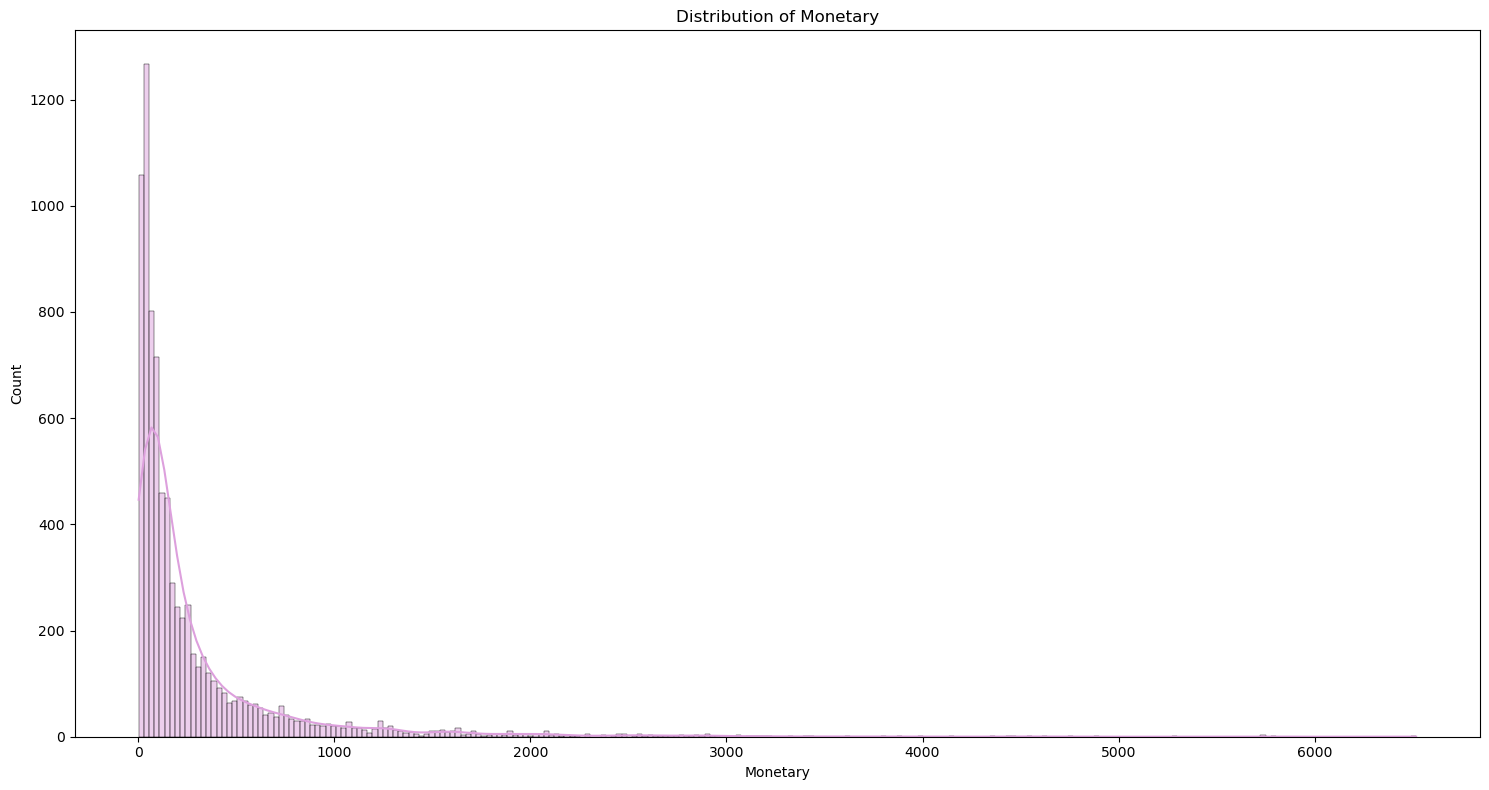

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

sns.histplot(data=df, x='Monetary', kde=True, ax=ax, color='plum')
ax.set_title('Distribution of Monetary')

plt.tight_layout()
plt.show()

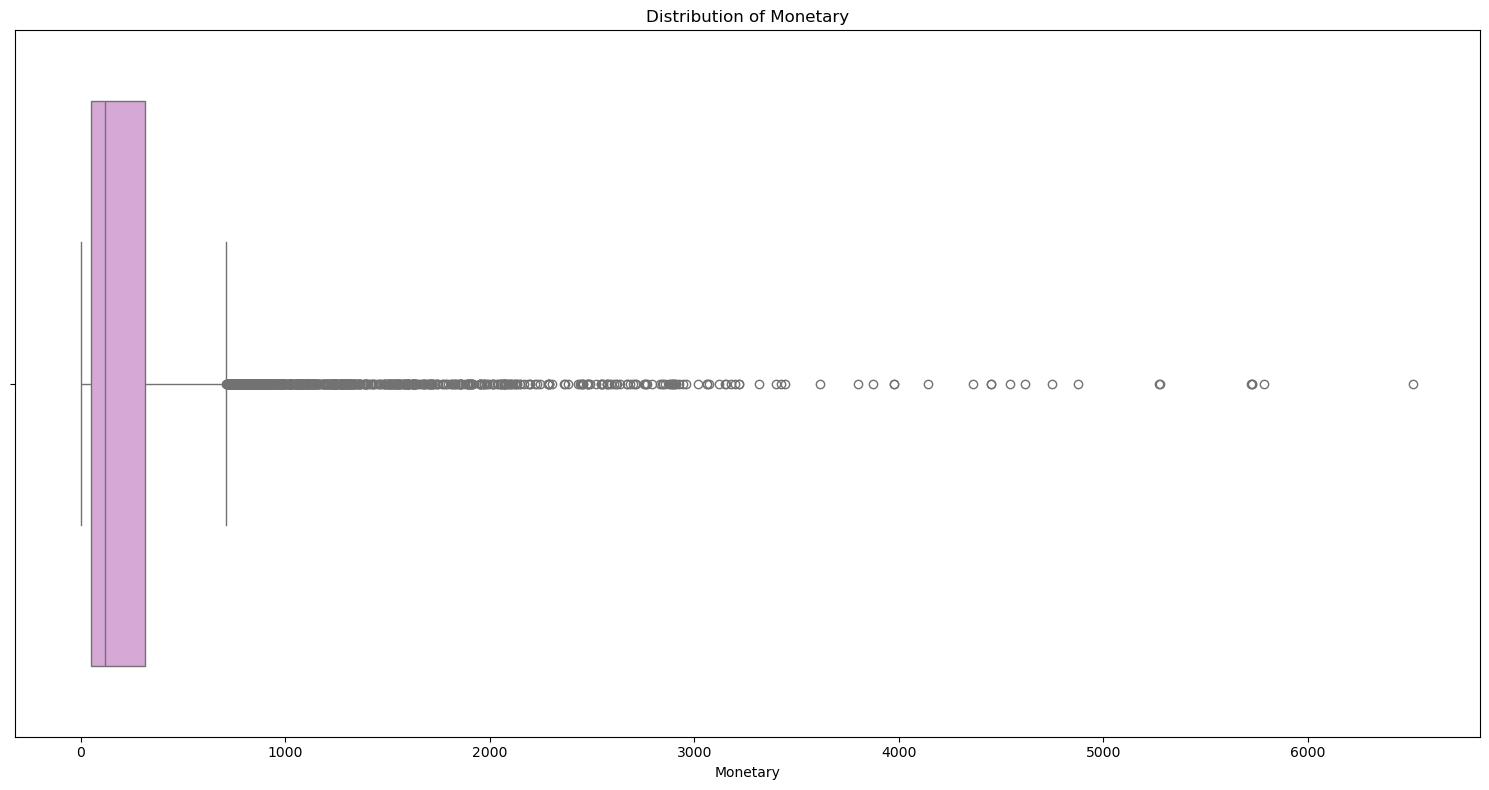

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

sns.boxplot(data=df, x='Monetary', color='plum')
ax.set_title('Distribution of Monetary')

plt.tight_layout()
plt.show()

# __2. Data Analysis__

In [18]:
import pandas as pd
import numpy as np

# Menentukan tanggal terakhir dalam dataset sebagai acuan 'today'
today_date = df['Recency'].max()

# Menghitung Recency, Frequency, dan Monetary untuk setiap pelanggan
df_rfm = df.groupby('Customer Name').agg({
    'Recency': lambda x: (today_date - x.max()).days,  # Recency: hari sejak pembelian terakhir
    'Frequency': 'nunique',  # Frequency: jumlah pesanan unik
    'Monetary': 'sum'  # Monetary: total nilai penjualan
}).reset_index()

# Mengubah nama kolom untuk RFM
df_rfm.columns = ['Customer Name', 'Recency', 'Frequency', 'Monetary']
df_rfm

,Customer Name,Recency,Frequency,Monetary
0,Aaron Bootman,252,11,4281
1,Aaron Cunningham,211,8,2463
2,Aaron Davey,636,4,2238
3,Aaron Macrossan,1199,1,81
4,Abbie Perry,97,4,1313
...,...,...,...,...
787,Zara Loton,116,3,1614
788,Zara Money,12,5,2862
789,Zoe Lanigan,173,4,3249
790,Zoe Lowin,5,4,1754


In [19]:
# Memastikan pelanggan yang telah memberikan nilai nyata bagi bisnis
df_rfm = df_rfm[df_rfm['Monetary'] > 0]
df_rfm

,Customer Name,Recency,Frequency,Monetary
0,Aaron Bootman,252,11,4281
1,Aaron Cunningham,211,8,2463
2,Aaron Davey,636,4,2238
3,Aaron Macrossan,1199,1,81
4,Abbie Perry,97,4,1313
...,...,...,...,...
787,Zara Loton,116,3,1614
788,Zara Money,12,5,2862
789,Zoe Lanigan,173,4,3249
790,Zoe Lowin,5,4,1754


In [20]:
# Fungsi untuk menetapkan skor Recency berdasarkan ambang batas yang lebih realistis untuk e-commerce
def score_recency(recency):
    if recency <= 30:  # Pelanggan yang melakukan transaksi dalam 30 hari terakhir
        return 5
    elif recency <= 60:  # Pelanggan yang melakukan transaksi dalam 31-60 hari
        return 4
    elif recency <= 90:  # Pelanggan yang melakukan transaksi dalam 61-90 hari
        return 3
    elif recency <= 180:  # Pelanggan yang melakukan transaksi dalam 91-180 hari
        return 2
    else:  # Pelanggan yang sudah lebih dari 180 hari tidak bertransaksi
        return 1

# Fungsi untuk menetapkan skor Frequency berdasarkan jumlah pembelian unik
def score_frequency(frequency):
    if frequency >= 12:  # Pelanggan yang melakukan pembelian lebih dari 12 kali (sekitar 1 kali per bulan)
        return 5
    elif frequency >= 8:  # Pelanggan yang melakukan pembelian antara 8 hingga 12 kali
        return 4
    elif frequency >= 5:  # Pelanggan yang melakukan pembelian antara 5 hingga 7 kali
        return 3
    elif frequency >= 2:  # Pelanggan yang melakukan pembelian 2 hingga 4 kali
        return 2
    else:  # Pelanggan yang hanya melakukan 1 kali pembelian
        return 1

# Fungsi untuk menetapkan skor Monetary berdasarkan nilai pembelian
def score_monetary(monetary):
    if monetary >= 5000:  # Pelanggan yang menghabiskan lebih dari $5000
        return 5
    elif monetary >= 2000:  # Pelanggan yang menghabiskan antara $2000 hingga $5000
        return 4
    elif monetary >= 1000:  # Pelanggan yang menghabiskan antara $1000 hingga $2000
        return 3
    elif monetary >= 500:  # Pelanggan yang menghabiskan antara $500 hingga $1000
        return 2
    else:  # Pelanggan yang menghabiskan kurang dari $500
        return 1

# Menerapkan fungsi untuk menilai setiap kolom
df_rfm['Recency_Score'] = df_rfm['Recency'].apply(score_recency)
df_rfm['Frequency_Score'] = df_rfm['Frequency'].apply(score_frequency)
df_rfm['Monetary_Score'] = df_rfm['Monetary'].apply(score_monetary)

# Gabungkan skor RFM menjadi satu kolom
df_rfm['RFM'] = df_rfm['Recency_Score'].astype(str) + df_rfm['Frequency_Score'].astype(str) + df_rfm['Monetary_Score'].astype(str)

# Tampilkan data hasil RFM
df_rfm.head()

,Customer Name,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM
0,Aaron Bootman,252,11,4281,1,4,4,144
1,Aaron Cunningham,211,8,2463,1,4,4,144
2,Aaron Davey,636,4,2238,1,2,4,124
3,Aaron Macrossan,1199,1,81,1,1,1,111
4,Abbie Perry,97,4,1313,2,2,3,223


In [21]:
df_rfm.sort_values(by='Frequency', ascending=False)

,Customer Name,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM
391,Jose Gambino,0,13,6824,5,5,5,555
537,Mark Washington,2,12,7846,5,5,5,555
423,Kayla Tearle,23,12,6637,5,5,5,555
0,Aaron Bootman,252,11,4281,1,4,4,144
294,Hayden Perkins,105,11,8567,2,4,5,245
...,...,...,...,...,...,...,...,...
359,Jay Collier,2,1,516,5,1,2,512
758,Tyler Whitehead,1309,1,1768,1,1,3,113
140,Claire Dilke,389,1,644,1,1,2,112
3,Aaron Macrossan,1199,1,81,1,1,1,111


In [22]:
df_rfm.describe(include=object)

,Customer Name,RFM
count,792,792
unique,792,68
top,Aaron Bootman,134
freq,1,65


In [23]:
df_rfm.describe()

,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score
count,792.000000,792.000000,792.000000,792.000000,792.000000,792.000000
mean,197.215909,5.198232,2962.511364,2.560606,2.719697,3.497475
std,220.965311,2.210731,2203.151282,1.553549,0.755739,1.100508
min,0.000000,1.000000,14.000000,1.000000,1.000000,1.000000
25%,43.000000,4.000000,1306.750000,1.000000,2.000000,3.000000
50%,119.500000,5.000000,2494.500000,2.000000,3.000000,4.000000
75%,277.250000,7.000000,4101.500000,4.000000,3.000000,4.000000
max,1412.000000,13.000000,16047.000000,5.000000,5.000000,5.000000


In [24]:
# Fungsi untuk menetapkan segmen berdasarkan RFM Score di konteks e-commerce
def segment_customer(df_rfm):
    if df_rfm['Recency_Score'] == 5 and df_rfm['Frequency_Score'] >= 4 and df_rfm['Monetary_Score'] >= 4:
        return 'Champions'
    elif df_rfm['Recency_Score'] >= 4 and df_rfm['Frequency_Score'] >= 3 and df_rfm['Monetary_Score'] >= 3:
        return 'Loyal Customers'
    elif df_rfm['Recency_Score'] >= 3 and df_rfm['Frequency_Score'] >= 3 and df_rfm['Monetary_Score'] >= 3:
        return 'Potential Loyalist'
    elif df_rfm['Recency_Score'] == 5 and df_rfm['Frequency_Score'] <= 2 and df_rfm['Monetary_Score'] <= 2:
        return 'Recent Users'
    elif df_rfm['Recency_Score'] == 4 and df_rfm['Frequency_Score'] <= 2 and df_rfm['Monetary_Score'] <= 2:
        return 'Promising'
    elif df_rfm['Recency_Score'] == 3 and df_rfm['Frequency_Score'] <= 2 and df_rfm['Monetary_Score'] <= 2:
        return 'Need Attention'
    elif df_rfm['Recency_Score'] <= 2 and df_rfm['Frequency_Score'] >= 3 and df_rfm['Monetary_Score'] >= 3:
        return 'At Risk'
    elif df_rfm['Recency_Score'] <= 2 and df_rfm['Frequency_Score'] == 2 and df_rfm['Monetary_Score'] == 2:
        return "Can't Lose Them"
    elif df_rfm['Recency_Score'] == 2 and df_rfm['Frequency_Score'] <= 1 and df_rfm['Monetary_Score'] <= 1:
        return 'About To Sleep'
    elif df_rfm['Recency_Score'] == 1 and df_rfm['Frequency_Score'] == 1 and df_rfm['Monetary_Score'] == 1:
        return 'Lost'
    else:
        return 'Hibernating'

# Mengganti RFM score dengan segmen yang sesuai
df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)

# Melihat hasil segmentasi
df_rfm[['Customer Name', 'Recency_Score', 'Frequency_Score', 'Monetary_Score', 'Segment']].head()

,Customer Name,Recency_Score,Frequency_Score,Monetary_Score,Segment
0,Aaron Bootman,1,4,4,At Risk
1,Aaron Cunningham,1,4,4,At Risk
2,Aaron Davey,1,2,4,Hibernating
3,Aaron Macrossan,1,1,1,Lost
4,Abbie Perry,2,2,3,Hibernating


In [25]:
segment_counts = df_rfm['Segment'].value_counts().sort_values(ascending=False)
segment_counts

Segment
Hibernating           248
At Risk               228
Loyal Customers       168
Can't Lose Them        48
Champions              34
Potential Loyalist     32
Lost                   16
Recent Users            7
Need Attention          6
Promising               3
About To Sleep          2
Name: count, dtype: int64

C:\Users\ICHA\AppData\Local\Temp\ipykernel_8776\325733314.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=segment_counts.index, x=segment_counts.values, palette="viridis")


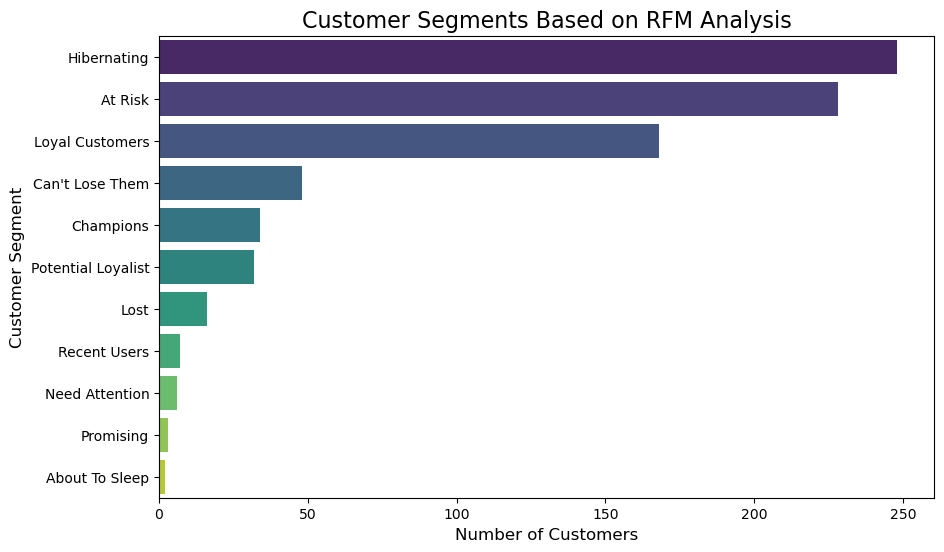

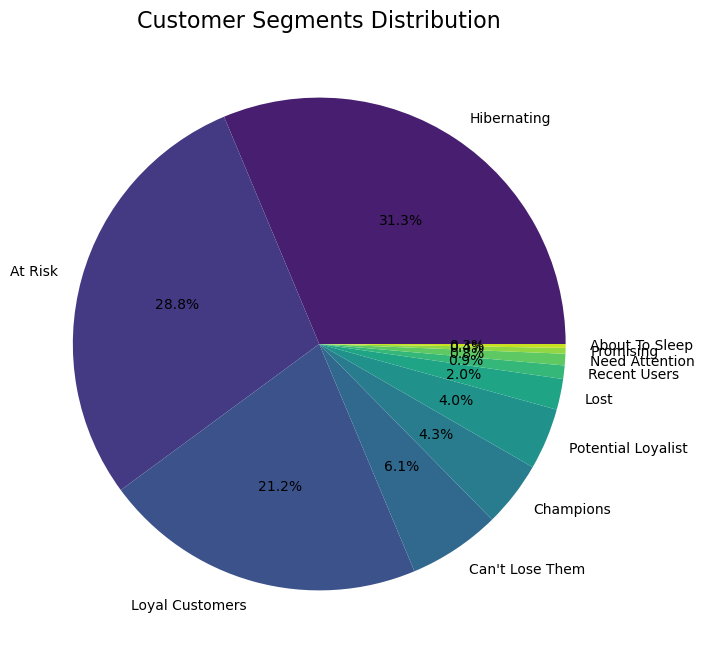

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung jumlah pelanggan per segmen
segment_counts = df_rfm['Segment'].value_counts().sort_values(ascending=False)

# Membuat bar chart
plt.figure(figsize=(10, 6))
sns.barplot(y=segment_counts.index, x=segment_counts.values, palette="viridis")
plt.title('Customer Segments Based on RFM Analysis', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)
# plt.grid()
plt.show()

# Membuat pie chart
plt.figure(figsize=(8, 8))
plt.pie(segment_counts, labels=segment_counts.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(segment_counts)))
plt.title('Customer Segments Distribution', fontsize=16)
plt.show()

In [27]:
segments_of_interest = ['Champions', 'Loyal Customers', 'Potential Loyalist', 'Recent Users', 'Promising', 'Need Attention', 'At Risk', "Can't Lose Them", 'About to Sleep', 'Lost', 'Hibernating']

result = df_rfm[df_rfm['Segment'].isin(segments_of_interest)].groupby('Segment').head(1)
result.sort_values('Segment')

,Customer Name,Recency,Frequency,Monetary,Recency_Score,Frequency_Score,Monetary_Score,RFM,Segment
0,Aaron Bootman,252,11,4281,1,4,4,144,At Risk
11,Adam Gibbs,111,4,815,2,2,2,222,Can't Lose Them
12,Adam Harte,30,8,4509,5,4,4,544,Champions
2,Aaron Davey,636,4,2238,1,2,4,124,Hibernating
3,Aaron Macrossan,1199,1,81,1,1,1,111,Lost
7,Abby Muramats,33,5,1112,4,3,3,433,Loyal Customers
122,Charles Rice,72,1,642,3,1,2,312,Need Attention
19,Alannah Callaway,79,5,3412,3,3,4,334,Potential Loyalist
92,Beverly Brooks,43,4,753,4,2,2,422,Promising
29,Alexis O'Flaherty,1,3,649,5,2,2,522,Recent Users


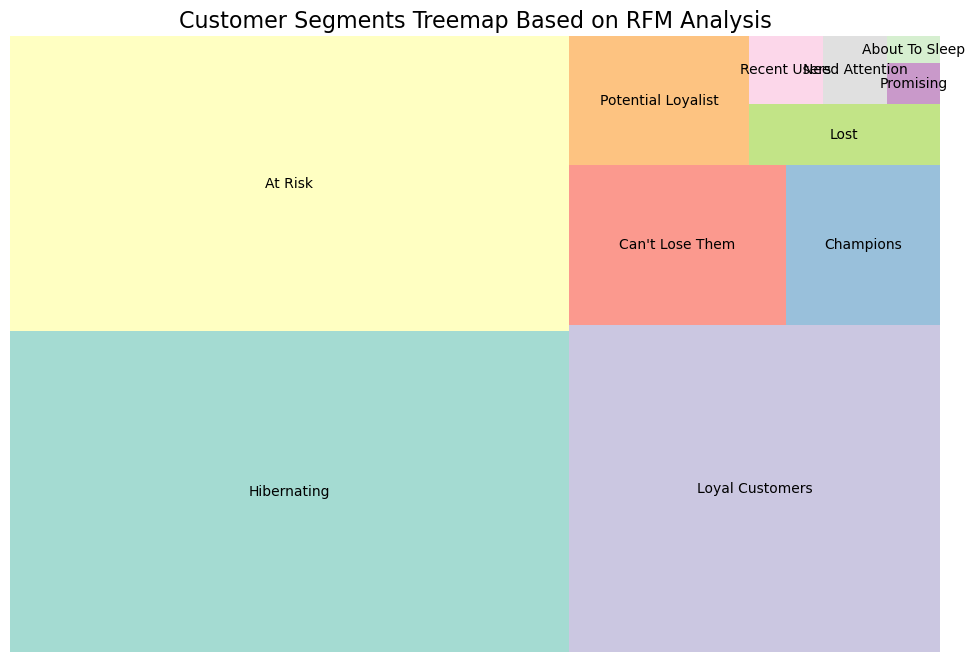

In [28]:
import squarify
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat treemap dengan warna yang lebih bervariasi untuk perbedaan segmen
plt.figure(figsize=(12, 8))
squarify.plot(sizes=segment_counts.values, label=segment_counts.index, alpha=.8, color=sns.color_palette('Set3', len(segment_counts)))
plt.title('Customer Segments Treemap Based on RFM Analysis', fontsize=16)
plt.axis('off')  # Menonaktifkan sumbu
plt.show()

# __Visualisasi Top 3 Customer Segment__

C:\Users\ICHA\AppData\Local\Temp\ipykernel_8776\1490839845.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(y=selected_segments.index, x=selected_segments.values, palette="viridis")


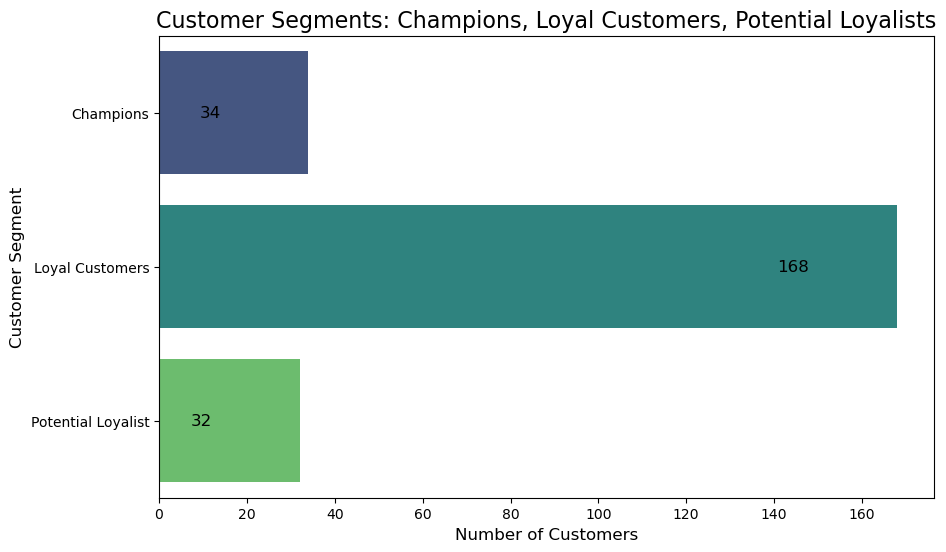

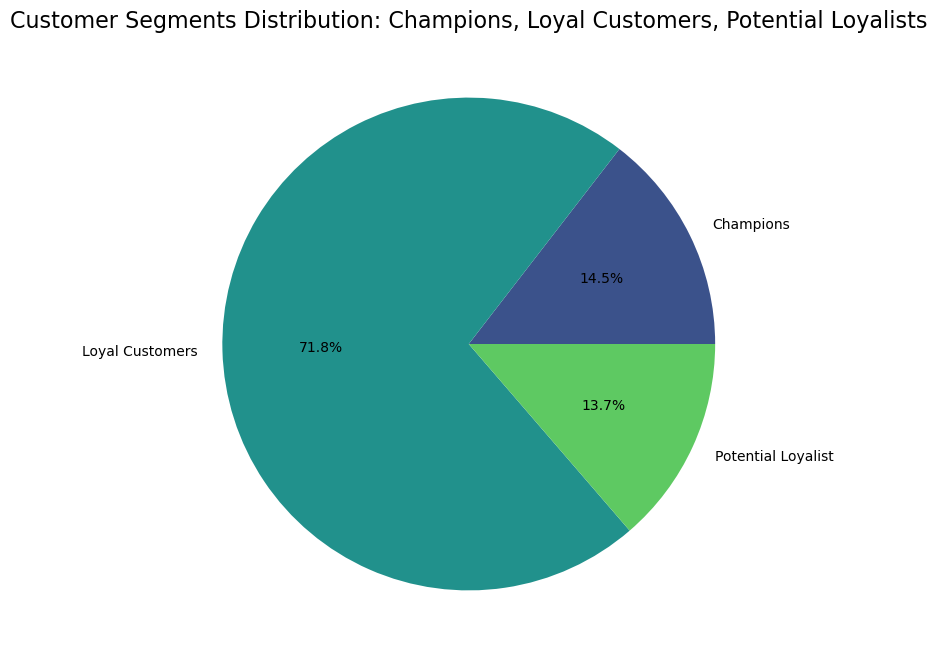

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Menghitung ulang jumlah pelanggan per segmen dari df_rfm
segment_counts = df_rfm['Segment'].value_counts().sort_values(ascending=False)

# Mengambil jumlah pelanggan untuk segmen 'Champions', 'Loyal Customers', dan 'Potential Loyalist'
selected_segments = segment_counts.loc[['Champions', 'Loyal Customers', 'Potential Loyalist']]

# Membuat bar chart dengan label yang tidak overlap di atas tiap bar
plt.figure(figsize=(10, 6))
barplot = sns.barplot(y=selected_segments.index, x=selected_segments.values, palette="viridis")
plt.title('Customer Segments: Champions, Loyal Customers, Potential Loyalists', fontsize=16)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Customer Segment', fontsize=12)

# Menambahkan label di atas bar dengan posisi yang lebih tepat
for i, value in enumerate(selected_segments.values):
    barplot.text(value - 20, i, str(value), va='center', ha='right', fontsize=12, color='black')

plt.show()

# Membuat pie chart untuk 3 segmen yang dipilih
plt.figure(figsize=(8, 8))
plt.pie(selected_segments.values, labels=selected_segments.index, autopct='%1.1f%%', colors=sns.color_palette('viridis', len(selected_segments)))
plt.title('Customer Segments Distribution: Champions, Loyal Customers, Potential Loyalists', fontsize=16)
plt.show()

In [30]:
# Menampilkan semua nama pelanggan yang termasuk dalam segmen 'Champions', 'Loyal Customers', dan 'Potential Loyalist'
selected_customers = df_rfm[df_rfm['Segment'].isin(['Champions', 'Loyal Customers', 'Potential Loyalist'])]

# Menampilkan kolom 'Customer Name' dan 'Segment' untuk melihat daftar nama pelanggan di segmen tersebut
selected_customers[['Customer Name', 'Segment']]


,Customer Name,Segment
7,Abby Muramats,Loyal Customers
12,Adam Harte,Champions
14,Adam Walpole,Loyal Customers
16,Aidan Rowe,Loyal Customers
19,Alannah Callaway,Potential Loyalist
...,...,...
781,Xavier Synan,Loyal Customers
784,Zachary Disher,Loyal Customers
785,Zachary Warner,Champions
788,Zara Money,Loyal Customers


In [31]:
# Menambahkan kolom baru 'nomor' untuk memberi nomor urut pada daftar pelanggan di segmen 'Champions'
champions_customers = df_rfm[df_rfm['Segment'] == 'Champions'].reset_index()

# Menampilkan kolom 'nomor', 'Customer Name', dan 'Segment'
champions_customers[['Customer Name', 'Segment']].head(10)

,Customer Name,Segment
0,Adam Harte,Champions
1,Alexis Code,Champions
2,Angelina Hurst,Champions
3,Anna Macdonald,Champions
4,Audrey Knowles,Champions
5,Charles Builder,Champions
6,Craig Rayner,Champions
7,Eloise Sykes,Champions
8,Evie Flockhart,Champions
9,Georgina Garner,Champions


In [32]:
# Menampilkan semua nama pelanggan yang termasuk dalam segmen 'Champions' saja
champions_customers = df_rfm[df_rfm['Segment'] == 'Champions'].reset_index()

# Menampilkan kolom 'nomor', 'Customer Name', dan 'Segment'
champions_customers[['Customer Name', 'Segment']].head(10)

,Customer Name,Segment
0,Adam Harte,Champions
1,Alexis Code,Champions
2,Angelina Hurst,Champions
3,Anna Macdonald,Champions
4,Audrey Knowles,Champions
5,Charles Builder,Champions
6,Craig Rayner,Champions
7,Eloise Sykes,Champions
8,Evie Flockhart,Champions
9,Georgina Garner,Champions


In [33]:
# Menampilkan semua nama pelanggan yang termasuk dalam segmen 'Loyal Customers' saja
loyal_customers = df_rfm[df_rfm['Segment'] == 'Loyal Customers'].reset_index()

# Menampilkan kolom 'nomor', 'Customer Name', dan 'Segment'
loyal_customers[['Customer Name', 'Segment']].head(10)


,Customer Name,Segment
0,Abby Muramats,Loyal Customers
1,Adam Walpole,Loyal Customers
2,Aidan Rowe,Loyal Customers
3,Alex Greenwood,Loyal Customers
4,Alexander Bennett,Loyal Customers
5,Alexandra Portus,Loyal Customers
6,Alta Nokes,Loyal Customers
7,Amanda Hutcherson,Loyal Customers
8,Amber Adams,Loyal Customers
9,Anna Kelly,Loyal Customers


In [34]:
# Menampilkan semua nama pelanggan yang termasuk dalam segmen 'Loyal Customers' saja
loyal_customers = df_rfm[df_rfm['Segment'] == 'Potential Loyalist'].reset_index()

# Menampilkan kolom 'nomor', 'Customer Name', dan 'Segment'
loyal_customers[['Customer Name', 'Segment']].head(10)

,Customer Name,Segment
0,Alannah Callaway,Potential Loyalist
1,Alice Black,Potential Loyalist
2,Alice Currie,Potential Loyalist
3,Angus Ibsch,Potential Loyalist
4,Archer Hort,Potential Loyalist
5,Ashton Charles,Potential Loyalist
6,Brooke Horton,Potential Loyalist
7,Charlie Power,Potential Loyalist
8,Cynthia Zielinski,Potential Loyalist
9,Erin Gill,Potential Loyalist


# __3. Comments and Actions__

In [35]:
df_rfm[['Segment', 'Recency', 'Frequency', 'Monetary']].groupby('Segment').agg(['mean', 'count','max'])

Recency             Frequency               Monetary  \
                          mean count   max      mean count max         mean   
Segment                                                                       
About To Sleep      121.500000     2   125  1.000000     2   1    52.000000   
At Risk             229.592105   228   762  6.412281   228  11  3797.083333   
Can't Lose Them     335.750000    48  1112  3.104167    48   4   783.687500   
Champions            13.970588    34    30  9.088235    34  13  5649.352941   
Hibernating         273.274194   248  1309  3.487903   248   8  2018.229839   
Lost                700.812500    16  1412  1.000000    16   1   170.250000   
Loyal Customers      29.696429   168    58  6.279762   168  11  3620.398810   
Need Attention       77.500000     6    89  3.166667     6   4   712.500000   
Potential Loyalist   73.718750    32    89  6.718750    32  10  4051.687500   
Promising            48.666667     3    53  2.666667     3   4   595.000000   
Recent Users         10.000000     7    26  2.428571     7   3   512.714286   

                                 
                   count    max  
Segment                          
About To Sleep         2     57  
At Risk              228  16047  
Can't Lose Them       48    999  
Champions             34  13191  
Hibernating          248   8701  
Lost                  16    470  
Loyal Customers      168  10466  
Need Attention         6    927  
Potential Loyalist    32  13056  
Promising              3    810  
Recent Users           7    854

Terdapat 3 segmen yang penting untuk menjaga __'Customer Retention'__:
1. Champions
2. About to Sleep
3. Can't Loose

#### **Actionable Recommendation untuk Meningkatkan Loyalitas dan Retensi Pelanggan pada XYZ E-Commerce**
Berdasarkan hasil analisis maka dapat dirumuskan strategi sebagai berikut:
##### __1. Fokus pada Pelanggan Terbaik (Champions)__
**Solusi:** Berikan penghargaan eksklusif seperti:
- **Program loyalitas VIP** dengan benefit khusus (diskon ekstra, hadiah loyalitas, atau akses prioritas ke produk baru).
- **Hadiah tambahan** pada pembelian tertentu untuk mempertahankan keterikatan mereka.

##### __2. Bangun Loyalitas Pelanggan Baru (Potential Loyalists)__
**Target:** Pelanggan yang memiliki pembelian baru-baru ini (low Recency), tetapi frekuensi dan monetary mereka belum signifikan.

**Solusi:** Ciptakan program untuk meningkatkan engagement, seperti:
- **Diskon pembelian** atau program referensi untuk mendorong mereka melakukan lebih banyak pembelian.
- Kirimkan **rekomendasi produk** berdasarkan pembelian pertama mereka, bisa produk yang berhubungan dengan produk pertama.
- Berikan insentif **free shipping** atau promosi terbatas untuk mendorong transaksi berikutnya.

##### __3. Menarik Kembali Pelanggan (At Risk)__
**Target:** Pelanggan dengan recency yang tinggi, tetapi frekuensi dan monetary yang cukup baik, menunjukkan mereka berpotensi tidak aktif lagi.

**Solusi:** Gunakan kampanye win-back untuk mengembalikan mereka:
- Kirimkan email untuk menarik kembali pelanggan dengan **penawaran eksklusif** seperti diskon besar atau bundling produk.
- Tawarkan **loyalty points** untuk transaksi berikutnya, sehingga mereka terdorong untuk melakukan pembelian lagi.

##### __4. Perbaiki Pelanggan yang Hampir Tidak Aktif (Hibernating)__
**Target:** Pelanggan dengan recency, frequency, dan monetary yang rendah, menunjukkan bahwa mereka hampir tidak aktif.

**Solusi:** Upayakan untuk membangkitkan kembali minat mereka dengan pendekatan personal:
- Kirimkan email dengan **penawaran khusus** untuk produk yang pernah mereka beli.
- Berikan insentif besar seperti **cashback** atau diskon pada momen tertentu untuk menarik perhatian mereka.

##### __5. Program Loyalitas Berkelanjutan__
**Solusi:**
- Buatlah program **loyalty points** atau reward system yang dapat diakumulasikan oleh pelanggan berdasarkan transaksi mereka. Semakin sering mereka berbelanja, semakin banyak keuntungan yang didapatkan.
- Berikan **rewards milestones**, seperti diskon setelah mencapai jumlah pembelian tertentu atau hadiah untuk pembelian rutin tiap periode waktu.

##### __6. Komunikasi dan Pengalaman__
**Solusi:** Gunakan data RFM untuk mengirim komunikasi yang dipersonalisasi sesuai dengan segmen pelanggan:
- Kirim **email promosi** berdasarkan produk yang mereka sukai atau beli sebelumnya.
- Berikan **rekomendasi produk** yang sesuai dengan kebiasaan belanja mereka atau berikan program **free delivery**.

---

#### __Kesimpulan:__
Dengan menerapkan strategi-strategi di atas, perusahaan XYZ E-Commerce dapat:
- Mempertahankan **pelanggan terbaik** melalui penghargaan dan perlakuan eksklusif.
- Membangun **loyalitas di kalangan pelanggan baru** yang menunjukkan potensi tinggi.
- Mengembalikan **pelanggan yang mulai tidak aktif** dengan kampanye retargeting dan penawaran khusus.
- Meningkatkan **pengalaman pelanggan** secara keseluruhan, sehingga meningkatkan retensi dan loyalitas jangka panjang.
